# იმპორტები

In [10]:
import os
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
import pandas as pd
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

# მონაცემების დალოუდება და ნახვა

In [11]:
# Data loading
train_img_dir = "../train_data/train/images"
train_mask_dir = "../train_data/train/masks"
test_img_dir = "../test_data/test/images"

all_files = sorted(os.listdir(train_img_dir))
test_files = sorted(os.listdir(test_img_dir))
print(f"Train+Val: {len(all_files)}, Test: {len(test_files)}")

Train+Val: 230, Test: 50


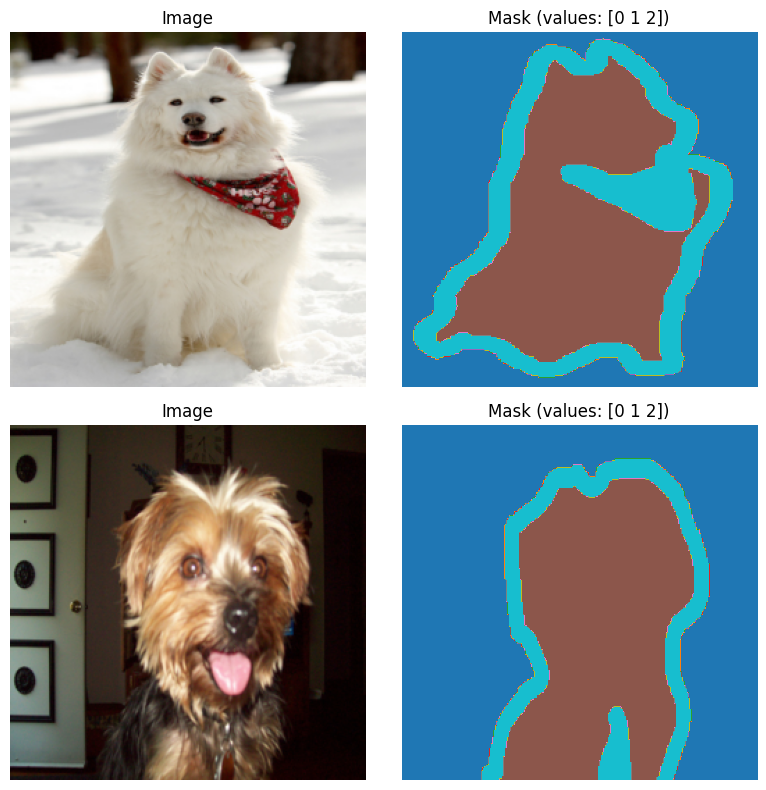

In [12]:
# Visualize 2 examples
fig, axes = plt.subplots(2, 2, figsize=(8, 8))
for i in range(2):
    img = np.array(Image.open(os.path.join(train_img_dir, all_files[i])))
    mask = np.array(Image.open(os.path.join(train_mask_dir, all_files[i])))
    axes[i, 0].imshow(img)
    axes[i, 0].set_title("Image")
    axes[i, 0].axis("off")
    axes[i, 1].imshow(mask, cmap="tab10", vmin=0, vmax=2)
    axes[i, 1].set_title(f"Mask (values: {np.unique(mask)})")
    axes[i, 1].axis("off")
plt.tight_layout()
plt.show()

# baseline

In [13]:
class SegDataset(Dataset):
    def __init__(self, img_dir, mask_dir=None, file_list=None):
        self.img_dir = img_dir
        self.mask_dir = mask_dir
        self.files = file_list if file_list else sorted(os.listdir(img_dir))

    def __len__(self):
        return len(self.files)

    def __getitem__(self, idx):
        fname = self.files[idx]
        img = np.array(Image.open(os.path.join(self.img_dir, fname)).convert("RGB"))
        img = torch.from_numpy(img).permute(2, 0, 1).float() / 255.0

        if self.mask_dir:
            mask = np.array(Image.open(os.path.join(self.mask_dir, fname)))
        else:
            mask = np.zeros((256, 256), dtype=np.int64)
        mask = torch.from_numpy(mask).long()
        return img, mask

In [14]:
import torch
import torch.nn as nn

class DownConvBlock(nn.Module):
    def __init__(self, in_channels, out_channels):
        super(DownConvBlock, self).__init__()

        self.model = nn.Sequential(
            nn.Conv2d(in_channels, out_channels, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),

            nn.Conv2d(out_channels, out_channels, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),

            nn.BatchNorm2d(out_channels)
        )

    def forward(self, x):
        return self.model(x)

class UpConvBlock(nn.Module):
    def __init__(self, in_channels, out_channels):
        super().__init__()

        self.up = nn.ConvTranspose2d(
            in_channels,
            out_channels,
            kernel_size=2,
            stride=2
        )

        self.conv = nn.Sequential(
            nn.Conv2d(out_channels * 2, out_channels, 3, padding=1),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True),

            nn.Conv2d(out_channels, out_channels, 3, padding=1),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True),
        )

    def forward(self, x, skip):
        x = self.up(x)

        # fix shape mismatch safety (optional but useful)
        if x.shape != skip.shape:
            x = torch.nn.functional.interpolate(x, size=skip.shape[2:])

        x = torch.cat([x, skip], dim=1)
        x = self.conv(x)

        return x

In [15]:
class TinyUNet(nn.Module):
    def __init__(self):
        super().__init__()
        self.enc1 = nn.Sequential(nn.Conv2d(3, 16, 3, padding=1), nn.ReLU())
        self.enc2 = nn.Sequential(nn.Conv2d(16, 32, 3, padding=1), nn.ReLU())
        self.pool = nn.MaxPool2d(2)
        
        self.bottleneck = nn.Sequential(nn.Conv2d(32, 64, 3, padding=1), nn.ReLU())

        self.up2 = nn.ConvTranspose2d(64, 32, 2, stride=2)
        self.dec2 = nn.Sequential(nn.Conv2d(64, 32, 3, padding=1), nn.ReLU())
        self.up1 = nn.ConvTranspose2d(32, 16, 2, stride=2)
        self.dec1 = nn.Sequential(nn.Conv2d(32, 16, 3, padding=1), nn.ReLU())

        self.final = nn.Conv2d(16, 3, 1)

    def forward(self, x):
        e1 = self.enc1(x)
        e2 = self.enc2(self.pool(e1))
        b = self.bottleneck(self.pool(e2))
        d2 = self.dec2(torch.cat([self.up2(b), e2], dim=1))
        d1 = self.dec1(torch.cat([self.up1(d2), e1], dim=1))
        return self.final(d1)

In [36]:
import torch
import torch.nn as nn
import torchvision.models as models


class ResNetEncoder(nn.Module):
    def __init__(self):
        super().__init__()

        resnet = models.resnet18(weights=None)

        state_dict = torch.load("./resnet18.pth", map_location="cpu")
        resnet.load_state_dict(state_dict)

        # Stem
        self.conv1 = resnet.conv1
        self.bn1 = resnet.bn1
        self.relu = resnet.relu
        self.maxpool = resnet.maxpool

        # Stages
        self.layer1 = resnet.layer1  # 64
        self.layer2 = resnet.layer2  # 128
        self.layer3 = resnet.layer3  # 256
        self.layer4 = resnet.layer4  # 512
    def forward(self, x):

        # Stem (CRITICAL FIX)
        x = self.resnet.conv1(x)
        x = self.resnet.bn1(x)
        x = self.resnet.relu(x)
        x = self.resnet.maxpool(x)

        # Encoder stages
        s1 = self.resnet.layer1(x)
        s2 = self.resnet.layer2(s1)
        s3 = self.resnet.layer3(s2)
        s4 = self.resnet.layer4(s3)

        # continue your UNet
        b = self.bottleneck(s4)

        d1 = self.up1(b, s4)
        d2 = self.up2(d1, s3)
        d3 = self.up3(d2, s2)
        d4 = self.up4(d3, s1)

        out = self.final_conv(d4)
        return out

In [ ]:

import tqdm
device = torch.device("mps")

train_ds = SegDataset("../train_data/train/images", "../train_data/train/masks", file_list=all_files[:200])
val_ds = SegDataset("../train_data/train/images", "../train_data/train/masks", file_list=all_files[200:])
test_ds = SegDataset("../test_data/test/images")

train_loader = DataLoader(train_ds, batch_size=8, shuffle=True, num_workers=0)
test_loader = DataLoader(test_ds, batch_size=8, num_workers=0)

model = UNet().to(device)
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.SGD(model.parameters(), lr=0.01)

for epoch in range(10):
    model.train()
    total_loss = 0
    for images, masks in tqdm.tqdm(train_loader):
        images, masks = images.to(device), masks.to(device)
        loss = criterion(model(images), masks)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
    print(f"Epoch {epoch+1}/10 | Loss: {total_loss/len(train_loader):.4f}")
    with torch.no_grad():
        images, masks = next(iter(test_loader))
        images = images.to(device)

        preds = model(images)
        preds = preds.permute(0, 2, 3, 1)

        # move to CPU
        images = images.cpu()
        masks = masks.cpu()
        preds = preds.cpu()

        # show first sample
        i = 0

        fig, ax = plt.subplots(1, 3, figsize=(12, 4))

        ax[0].imshow(images[i].permute(1, 2, 0))
        ax[0].set_title("Image")
        ax[0].axis("off")

        ax[1].imshow(masks[i].squeeze(), cmap="gray")
        ax[1].set_title("Ground Truth")
        ax[1].axis("off")

        ax[2].imshow(preds[i].squeeze(), cmap="gray")
        ax[2].set_title("Prediction")
        ax[2].axis("off")

        plt.tight_layout()
        plt.show()

  0%|          | 0/25 [00:00<?, ?it/s]


RuntimeError: Given groups=1, weight of size [64, 64, 3, 3], expected input[8, 3, 256, 256] to have 64 channels, but got 3 channels instead

: 

# საბმიშენის დაგენერირება

In [23]:
model.eval()
test_preds = []
with torch.no_grad():
    for images, _ in test_loader:
        preds = model(images.to(device)).argmax(1).cpu().numpy()
        test_preds.append(preds)
test_preds = np.concatenate(test_preds).astype(np.uint8)

rows = []
for i in range(len(test_preds)):
    pixels = " ".join(map(str, test_preds[i].flatten()))
    rows.append({"subtaskID": 1, "datapointID": i, "answer": pixels})

df = pd.DataFrame(rows)
df.to_csv("submission.csv", index=False)

print(f"Saved submission.csv — {len(test_preds)} images")

Saved submission.csv — 50 images
